# RR Lyrae Period Measurement — Rubin DP2 × VSX (all via lsdb HATS)
---
This notebook measures pulsation periods for **100 RR Lyrae stars** using:

| Step | Tool |
|------|------|
| Variable-star catalog | VSX — loaded as a remote HATS catalog via **`lsdb`** |
| Photometric time series | Rubin DP2 — local HATS catalog via **`lsdb`** |
| Footprint filter | `lsdb` box search on the DC2 region, applied to VSX |
| Spatial cross-match | `lsdb.crossmatch` — native HEALPix-aware join |
| Period analysis | `astropy.timeseries.LombScargle` |
| Validation | LS period vs. VSX reference period |

### Why load VSX through lsdb too?
A VizieR `astroquery` query over the DC2 field returns only ~2 RR Lyrae — not
because few exist, but because the VSX HTTP query interface caps results and the
coordinate-range filter is unreliable.  
CDS provides VSX as a **HATS-on-the-fly** catalog at  
`https://vizcat.cds.unistra.fr/hats/B/vsx/vsx/`  
`lsdb.read_hats()` reads it lazily; a box search then pulls only the  
DC2-footprint pixels, and `lsdb.crossmatch()` joins the two catalogs entirely  
within the HATS framework — no row-count caps, no XML encoding issues.

### Prerequisites
```bash
pip install lsdb astropy pandas numpy matplotlib
```
> `lsdb` pulls in `dask`, `hats`, and `nested-pandas` automatically.

## 0 · Imports & notebook settings

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from IPython.display import display

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.timeseries import LombScargle

import lsdb
from lsdb import BoxSearch
import nested_pandas as npd

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({
    "figure.dpi"    : 120,
    "axes.grid"     : True,
    "grid.alpha"    : 0.3,
    "font.size"     : 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
})
print("Imports OK ✓")

Imports OK ✓


## 1 · Configuration

In [2]:
# ── Paths / URLs ────────────────────────────────────────────────────────────────
DP2_HATS_PATH = Path("/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/object_collection")
VSX_HATS_URL  = "https://vizcat.cds.unistra.fr/hats/B/vsx/vsx/"
OUTPUT_DIR    = Path("rr_lyrae_output")

# ── DC2 sky footprint ────────────────────────────────────────────────────────────
DC2_RA_MIN  =  55.0   # deg
DC2_RA_MAX  =  75.0   # deg
DC2_DEC_MIN = -44.0   # deg
DC2_DEC_MAX = -27.0   # deg

# ── Sample & cross-match settings ────────────────────────────────────────────────
N_STARS          = 100    # max RR Lyrae to process after filtering
XMATCH_RADIUS    = 1.0    # arcsec
MIN_EPOCHS       = 20     # minimum per-band detections for LS fit

# ── Period search ────────────────────────────────────────────────────────────────
PERIOD_MIN       = 0.2    # days
PERIOD_MAX       = 1.0    # days
LS_FAP_THRESHOLD = 0.01
BAND_PREF        = ["r", "i", "g"]

# ── Display ──────────────────────────────────────────────────────────────────────
PLOT_N = 10

# ── DP2 nested-column schema ─────────────────────────────────────────────────────
LC_COLUMN   = "diaObject_forcedSourceOnDiaObject"
MJD_COL     = "midpointMjdTai"
FLUX_COL    = "psfFlux"
FLUXERR_COL = "psfFluxErr"
BAND_COL    = "band"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"DP2 HATS  : {DP2_HATS_PATH}")
print(f"VSX HATS  : {VSX_HATS_URL}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")
print(f"DC2 box   : RA {DC2_RA_MIN}–{DC2_RA_MAX}°,  Dec {DC2_DEC_MIN}–{DC2_DEC_MAX}°")

DP2 HATS  : /sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/object_collection
VSX HATS  : https://vizcat.cds.unistra.fr/hats/B/vsx/vsx/
Output dir: /home/b/brantd/notebooks_lf/sprints/2026/03_12/homework_4/rr_lyrae_output
DC2 box   : RA 55.0–75.0°,  Dec -44.0–-27.0°


## 2 · Open Both HATS Catalogs

Both catalogs are opened **lazily** — no data is read yet, only partition  
metadata.  `lsdb` will restrict I/O to the HEALPix pixels that overlap  
our queries when we call `.compute()`.

In [3]:
# Local DP2 object collection (cluster filesystem)
dp2 = lsdb.read_hats(DP2_HATS_PATH)
print("DP2 catalog:")
print(dp2)
print()

# Remote VSX HATS-on-the-fly (CDS server)
vsx_full = lsdb.read_hats(VSX_HATS_URL)
print("VSX catalog:")
print(vsx_full)
print()
print("VSX columns:", vsx_full.columns.tolist())

DP2 catalog:
Dask NestedFrame Structure:
                           coord_dec    coord_decErr         coord_ra     coord_raErr       g_psfFlux    g_psfFluxErr        g_psfMag     g_psfMagErr       i_psfFlux    i_psfFluxErr        i_psfMag     i_psfMagErr        objectId           patch       r_psfFlux    r_psfFluxErr        r_psfMag     r_psfMagErr          refBand     shape_flag        shape_xx        shape_xy        shape_yy           tract       u_psfFlux    u_psfFluxErr        u_psfMag     u_psfMagErr       y_psfFlux    y_psfFluxErr        y_psfMag     y_psfMagErr       z_psfFlux    z_psfFluxErr        z_psfMag     z_psfMagErr                                                                                                                                                                                                                                                                                                                                                                          

## 3 · Filter VSX to the DC2 Footprint and RR Lyrae Types

`BoxSearch` restricts lsdb to the HEALPix pixels that overlap the DC2 bounding  
box — only those pixels are downloaded from the CDS server.  
We then filter to RR Lyrae subtypes and require a known period.

In [4]:
# Lazy spatial filter — touches only the relevant HEALPix pixels
vsx_box = vsx_full.box_search(
    ra=(DC2_RA_MIN, DC2_RA_MAX),
    dec=(DC2_DEC_MIN, DC2_DEC_MAX),
)

# Compute: download + filter the small DC2-footprint subset
vsx_dc2 = vsx_box.compute()
print(f"VSX objects in DC2 box (all types): {len(vsx_dc2)}")

# Keep only RR Lyrae subtypes with a known period
rr_mask = vsx_dc2["Type"].astype(str).str.strip().str.startswith("RR")
has_per = vsx_dc2["Period"].notna() & (vsx_dc2["Period"] > 0)
vsx_rr  = vsx_dc2[rr_mask & has_per].head(N_STARS).reset_index(drop=True)

print(f"RR Lyrae with known period      : {len(vsx_rr)}")
display(vsx_rr[["OID", "Name", "RAJ2000", "DEJ2000", "Type", "Period"]].head(10))

VSX objects in DC2 box (all types): 9507
RR Lyrae with known period      : 0


,OID,Name,RAJ2000,DEJ2000,Type,Period


(<Figure size 1200x600 with 3 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - B/vsx/vsx'}>)

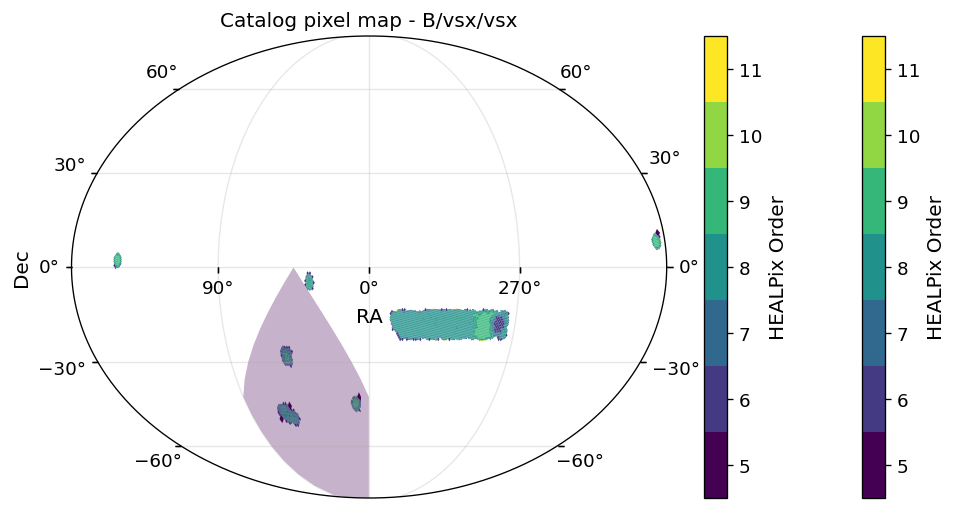

In [10]:
dp2.plot_pixels()
vsx_box.plot_pixels(alpha=0.3)

### In-field VSX positions and period distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(vsx_rr["RAJ2000"], vsx_rr["DEJ2000"],
           s=15, color="tomato", zorder=3,
           label=f"VSX RR Lyrae (n={len(vsx_rr)})")
box_ra  = [DC2_RA_MIN,  DC2_RA_MAX,  DC2_RA_MAX,  DC2_RA_MIN,  DC2_RA_MIN]
box_dec = [DC2_DEC_MIN, DC2_DEC_MIN, DC2_DEC_MAX, DC2_DEC_MAX, DC2_DEC_MIN]
ax.plot(box_ra, box_dec, "k--", lw=1, label="DC2 footprint")
ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title("VSX RR Lyrae — DC2 field"); ax.legend(fontsize=9)

ax2 = axes[1]
pvals = vsx_rr["Period"].astype(float).values
ax2.hist(pvals, bins=20, color="steelblue", edgecolor="white", lw=0.4)
ax2.axvline(np.median(pvals), color="tomato", ls="--",
            label=f"median = {np.median(pvals):.3f} d")
ax2.set_xlabel("Period (days)"); ax2.set_ylabel("Count")
ax2.set_title("VSX catalog periods (DC2 field)"); ax2.legend()
plt.tight_layout()

## 4 · Cross-Match VSX RR Lyrae × DP2 (lsdb native)

We wrap the filtered VSX subset back into an lsdb catalog and call  
`lsdb.crossmatch()`.  lsdb restricts the DP2 Parquet reads to only the  
HEALPix pixels containing our VSX positions.

In [ ]:
# Wrap filtered VSX DataFrame back into lsdb
vsx_lsdb = lsdb.from_dataframe(
    vsx_rr.rename(columns={"RAJ2000": "ra", "DEJ2000": "dec"}),
    ra_column="ra",
    dec_column="dec",
)

# Native HATS cross-match
xmatch = vsx_lsdb.crossmatch(
    dp2,
    radius_arcsec=XMATCH_RADIUS,
    n_neighbors=1,
    suffixes=("_vsx", "_dp2"),
)

xmatch_df = xmatch.compute()
print(f"Cross-matches: {len(xmatch_df)} / {len(vsx_rr)} VSX RR Lyrae")
display(xmatch_df.head(5))

## 5 · Unpack Nested Light-Curve Columns

The DP2 `object_collection` stores per-epoch photometry in a **nested column**.  
We explode it into a flat per-epoch DataFrame.

In [ ]:
def unpack_lightcurves(xmatch_df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """Explode the nested LC column → {oid: per-epoch DataFrame}."""
    lightcurves = {}

    if LC_COLUMN in xmatch_df.columns:
        for _, row in xmatch_df.iterrows():
            oid = str(row.get("OID_vsx", row.name))
            lc  = row[LC_COLUMN]
            if lc is None or (hasattr(lc, "__len__") and len(lc) == 0):
                continue
            lc_df = (lc.to_flat() if hasattr(lc, "to_flat")
                     else pd.DataFrame(lc))
            lc_df = lc_df.rename(columns={
                MJD_COL: "mjd", FLUX_COL: "flux",
                FLUXERR_COL: "flux_err", BAND_COL: "band",
            })
            if not {"mjd", "flux", "flux_err", "band"}.issubset(lc_df.columns):
                continue
            lc_df = lc_df[["mjd", "flux", "flux_err", "band"]].dropna()
            if len(lc_df) >= MIN_EPOCHS:
                lightcurves[oid] = lc_df
    else:
        print("⚠ Nested column not found — trying flat wide-column schema …")
        for _, row in xmatch_df.iterrows():
            oid, rows = str(row.get("OID_vsx", row.name)), []
            for band in BAND_PREF:
                mc = f"{MJD_COL}_{band}"; fc = f"{FLUX_COL}_{band}"
                ec = f"{FLUXERR_COL}_{band}"
                if all(c in xmatch_df.columns for c in [mc, fc, ec]):
                    rows.append({"mjd": row[mc], "flux": row[fc],
                                 "flux_err": row[ec], "band": band})
            if rows:
                lc_df = pd.DataFrame(rows).dropna()
                if len(lc_df) >= MIN_EPOCHS:
                    lightcurves[oid] = lc_df

    print(f"Light curves unpacked: {len(lightcurves)} / {len(xmatch_df)} "
          f"stars with ≥ {MIN_EPOCHS} epochs")
    return lightcurves

lightcurves = unpack_lightcurves(xmatch_df)

### Epoch counts per matched star

In [ ]:
epoch_counts = {oid: len(df) for oid, df in lightcurves.items()}

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(range(len(epoch_counts)),
       sorted(epoch_counts.values(), reverse=True),
       color="steelblue", width=1.0)
ax.axhline(MIN_EPOCHS, color="tomato", ls="--", lw=1,
           label=f"MIN_EPOCHS = {MIN_EPOCHS}")
ax.set_xlabel("Star rank (sorted by epoch count)")
ax.set_ylabel("Epochs")
ax.set_title(f"DP2 epoch counts — {len(epoch_counts)} cross-matched stars")
ax.legend()
plt.tight_layout()

## 6 · Lomb-Scargle Period Measurement

Flux → AB magnitude, then `LombScargle.autopower()` over 0.2–1.0 days.  
Band preference: **r → i → g**.

In [ ]:
def flux_to_mag(flux, flux_err, zp=3631.0):
    with np.errstate(divide="ignore", invalid="ignore"):
        mag     = -2.5 * np.log10(flux / zp)
        mag_err = (2.5 / np.log(10)) * np.abs(flux_err / flux)
    return mag, mag_err


def measure_period(df: pd.DataFrame) -> dict:
    for band in BAND_PREF:
        s = df[df["band"] == band].dropna(subset=["mjd", "flux", "flux_err"])
        s = s[s["flux"] > 0]
        if len(s) >= MIN_EPOCHS:
            break
    else:
        return {}

    t   = s["mjd"].values.astype(float)
    mag, mag_err = flux_to_mag(s["flux"].values.astype(float),
                               s["flux_err"].values.astype(float))
    ok  = np.isfinite(mag) & np.isfinite(mag_err) & (mag_err > 0)
    t, mag, mag_err = t[ok], mag[ok], mag_err[ok]
    if len(t) < MIN_EPOCHS:
        return {}

    ls          = LombScargle(t, mag, mag_err)
    freq, power = ls.autopower(
        minimum_frequency=1.0 / PERIOD_MAX,
        maximum_frequency=1.0 / PERIOD_MIN,
        samples_per_peak=10,
    )
    idx = np.argmax(power)
    return dict(
        period_days = 1.0 / freq[idx],
        power       = float(power[idx]),
        fap         = float(ls.false_alarm_probability(power[idx])),
        band        = band,
        n_epochs    = int(len(t)),
        freq        = freq,
        ls_power    = power,
        t=t, mag=mag, mag_err=mag_err,
    )

In [ ]:
vsx_period_map = dict(zip(vsx_rr["OID"].astype(str),
                          vsx_rr["Period"].astype(float)))

records = []
for oid, df in lightcurves.items():
    res = measure_period(df)
    if not res:
        continue
    records.append(dict(
        oid        = oid,
        period_ls  = res["period_days"],
        period_vsx = vsx_period_map.get(oid, np.nan),
        ls_power   = res["power"],
        ls_fap     = res["fap"],
        band       = res["band"],
        n_epochs   = res["n_epochs"],
        freq       = res["freq"],
        ls_pw      = res["ls_power"],
        t          = res["t"],
        mag        = res["mag"],
        mag_err    = res["mag_err"],
    ))

results = pd.DataFrame(records)
print(f"Period measurements: {len(results)} stars")
display(results[["oid","period_ls","period_vsx","ls_fap","band","n_epochs"]].head(10))

## 7 · Individual Periodograms

LS power spectrum for the first 6 stars.  
**Red** = LS best period · **Gold dashed** = VSX reference (where available).

In [ ]:
n_show = min(6, len(results))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.8 * n_show), sharex=False)
if n_show == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, results.head(n_show).iterrows()):
    ax.plot(1.0 / row["freq"], row["ls_pw"], lw=0.8, color="steelblue")
    ax.axvline(row["period_ls"], color="tomato", lw=1.5,
               label=f"LS = {row['period_ls']:.4f} d")
    if not np.isnan(row["period_vsx"]):
        ax.axvline(row["period_vsx"], color="gold", lw=1.5, ls="--",
                   label=f"VSX = {row['period_vsx']:.4f} d")
    ax.set_xlim(PERIOD_MIN, PERIOD_MAX)
    ax.set_ylabel("LS Power")
    ax.set_title(f"OID {row['oid']}  ·  {row['band']}-band  ·  "
                 f"{row['n_epochs']} pts  ·  FAP = {row['ls_fap']:.2e}")
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Period (days)")
fig.suptitle("Lomb-Scargle Periodograms", fontsize=13, y=1.01)
plt.tight_layout()

## 8 · Phase-Folded Light Curves

Folded at the LS period, plotted over two cycles.

In [ ]:
n_show = min(PLOT_N, len(results))
ncols, nrows = 2, int(np.ceil(n_show / 2))
band_colors  = {"g": "#4daf4a", "r": "#e41a1c", "i": "#984ea3"}

fig = plt.figure(figsize=(13, 3.4 * nrows))
gs  = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

for idx, (_, row) in enumerate(results.head(n_show).iterrows()):
    P     = row["period_ls"]
    phase = (row["t"] % P) / P
    order = np.argsort(phase)
    color = band_colors.get(row["band"], "steelblue")
    ax    = fig.add_subplot(gs[idx // ncols, idx % ncols])
    for offset in (0, 1):
        ax.errorbar(phase[order] + offset, row["mag"][order],
                    yerr=row["mag_err"][order],
                    fmt=".", ms=3, elinewidth=0.5, color=color, alpha=0.65)
    ax.invert_yaxis()
    ax.set_xlim(0, 2)
    ax.set_xlabel("Phase"); ax.set_ylabel(f"{row['band']} [mag]")
    vsx_str = (f"  (VSX {row['period_vsx']:.4f} d)"
               if not np.isnan(row["period_vsx"]) else "")
    ax.set_title(f"OID {row['oid']}\nP = {P:.4f} d{vsx_str}", fontsize=10)

fig.suptitle("Phase-Folded RR Lyrae Light Curves — Rubin DP2 (local HATS)",
             fontsize=13)
plt.tight_layout()

## 9 · LS vs VSX Period Comparison

Left: 1:1 scatter coloured by log₁₀(FAP). Alias lines at ½×P and 2×P.  
Right: residual histogram ΔP = P_LS − P_VSX.

In [ ]:
sub = results.dropna(subset=["period_vsx"]).copy()
sub["delta_P"] = sub["period_ls"] - sub["period_vsx"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(sub["period_vsx"], sub["period_ls"],
                c=np.log10(sub["ls_fap"].clip(1e-20, 1)),
                cmap="viridis_r", s=35, edgecolors="k", lw=0.3, alpha=0.85)
cb = fig.colorbar(sc, ax=ax); cb.set_label("log₁₀(FAP)")
lim = [PERIOD_MIN - 0.02, PERIOD_MAX + 0.02]
ax.plot(lim, lim,               "k--", lw=1, label="1:1")
ax.plot(lim, [x/2 for x in lim], ":", color="tomato",    lw=1, label="½×P")
ax.plot(lim, [x*2 for x in lim], ":", color="steelblue", lw=1, label="2×P")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("VSX Period (days)"); ax.set_ylabel("LS Period (days)")
ax.set_title("Period recovery: LS vs VSX"); ax.legend(fontsize=9)

ax2 = axes[1]
ax2.hist(sub["delta_P"], bins=25, color="steelblue", edgecolor="white", lw=0.4)
ax2.axvline(0, color="k", lw=1, ls="--")
ax2.axvline(sub["delta_P"].median(), color="tomato", lw=1.5, ls="--",
            label=f"median Δ = {sub['delta_P'].median():.4f} d")
ax2.set_xlabel("ΔP = P_LS − P_VSX (days)"); ax2.set_ylabel("Count")
ax2.set_title("Period residuals"); ax2.legend()

fig.suptitle("Lomb-Scargle Period Recovery — Rubin DP2 RR Lyrae", fontsize=13)
plt.tight_layout()

## 10 · Summary Statistics

In [ ]:
n_sig   = (results["ls_fap"] < LS_FAP_THRESHOLD).sum()
n_cmp   = len(sub)
n_match = (sub[(sub["ls_fap"] < LS_FAP_THRESHOLD) &
               (sub["delta_P"].abs() < 0.01)].shape[0])

print(f"{'VSX RR Lyrae in DC2 box':.<45s} {len(vsx_rr)}")
print(f"{'Cross-matched in DP2 HATS':.<45s} {len(xmatch_df)}")
print(f"{'With ≥ MIN_EPOCHS detections':.<45s} {len(lightcurves)}")
print(f"{'LS period measured':.<45s} {len(results)}")
print(f"{'Significant (FAP < {:.0e})'.format(LS_FAP_THRESHOLD):.<45s} {n_sig}")
if n_cmp:
    print(f"{'Compared to VSX reference':.<45s} {n_cmp}")
    print(f"{'Period match within 0.01 d (FAP-sig)':.<45s} {n_match}")
    print(f"{'Median |ΔP|':.<45s} {sub['delta_P'].abs().median():.5f} d")
    print(f"{'RMS ΔP':.<45s} {sub['delta_P'].std():.5f} d")

print()
display(
    results[["oid","period_ls","period_vsx","ls_fap","band","n_epochs"]]
    .sort_values("ls_fap").reset_index(drop=True)
    .style
    .format({"period_ls":"{:.5f}", "period_vsx":"{:.5f}", "ls_fap":"{:.2e}"})
    .background_gradient(subset="ls_fap", cmap="RdYlGn_r")
    .set_caption("RR Lyrae — Lomb-Scargle periods, sorted by FAP")
)

## 11 · Save Results

In [ ]:
csv_path = OUTPUT_DIR / "rr_lyrae_periods.csv"
results[["oid","period_ls","period_vsx","ls_power","ls_fap","band","n_epochs"]]    .to_csv(csv_path, index=False)
print(f"CSV saved  → {csv_path}")

fig_path = OUTPUT_DIR / "period_comparison.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Plot saved → {fig_path}")